# Predicting Utilization

Our idea for the prediction business case is to use a neural network, as this model class is expected to provide the highest predictive power for complex and non-linear utilization patterns.


However, to justify the added model complexity, we first establish a benchmark using linear and polynomial regression models.

---

### Target Variable (see also in feature_engineering.ipynb)

The target variable is the **total occupied charging minutes per hour**. We can see that the maximum possible utilization per hour is 3120 minutes which are equivalent to 3120 minutes / 60 minutes = 52 stations.

---

### Performance Evaluation Criteria

To assess whether a model (Regression model or Neural Network) is suitable for operational and strategic decision-making by a charging hub operator, the model performance is evaluated
along three complementary dimensions.


#### 1. Operational Accuracy

How many charging minutes per hour does the model misestimate on average?
→ This determines whether short-term planning (e.g. load management) is feasible.

**Metric used:** Mean Absolute Error (MAE)

The MAE is measured in minutes per hour and directly quantifies the average absolute deviation between predicted and observed occupied charging minutes. Because of its intuitive interpretation in the original unit of the target variable, MAE is particularly suitable for operational decision-making.


#### 2. Relative Accuracy Compared to Site Capacity

How large are the prediction errors relative to the maximum possible utilization?
→ This allows interpretation in percentage terms and comparison across sites.

**Metric used:** MAE relative to maximum capacity

The MAE is expressed as a percentage of the maximum theoretical utilization
(52 charging stations × 60 minutes = 3120 minutes per hour). This normalization
provides a scale-independent measure of prediction accuracy and facilitates
comparability across different locations.


#### 3. Explanatory Power

Does the model capture the structural patterns of utilization over time?
→ Important to assess whether predictions are systematic or mostly noise.

**Metric used:** Coefficient of determination (R²)

The R² score indicates the proportion of variance in hourly utilization that is
explained by the model. High R² values suggest that the model successfully
captures systematic demand patterns rather than random fluctuations.


#### Training and Validation Monitoring

In addition to the evaluation metrics above, the Root Mean Squared Error (RMSE) is monitored during training and validation. RMSE is more sensitive to large errors than MAE and is therefore useful for
assessing convergence behavior, overfitting tendencies, and the stability of
the learning process across epochs.

---

Lets start with the models!

## Linear and Polynomial Regression Models

#### Import necessary important Libraries

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Read in the Data

In [2]:
site1 = pd.read_csv("FINAL1.csv")

In [3]:
site1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23594 entries, 0 to 23593
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                23594 non-null  int64  
 1   hour                      23594 non-null  int64  
 2   weekday                   23594 non-null  int64  
 3   dayOfMonth                23594 non-null  int64  
 4   month                     23594 non-null  int64  
 5   year                      23594 non-null  int64  
 6   total minutes of parking  23594 non-null  float64
 7   temperature               23594 non-null  float64
 8   cloud_cover               23594 non-null  float64
 9   pressure                  23594 non-null  float64
 10  windspeed                 23594 non-null  float64
 11  precipitation             23594 non-null  float64
 12  felt_temperature          23594 non-null  float64
 13  is_holiday                23594 non-null  int64  
 14  covid 

In [4]:
site1["total minutes of parking"].describe()

count    23594.000000
mean       467.155662
std        958.149017
min          0.000000
25%          0.000000
50%          0.000000
75%        214.683333
max       3120.000000
Name: total minutes of parking, dtype: float64

#### Create the target and the features

In [5]:
y = site1["total minutes of parking"]
X = site1.drop(columns=["total minutes of parking"])

#### Split the data

In [6]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

- X_train, y_train → 60%: Training set

- X_val, y_val → 20%: Validation set

- X_test, y_test → 20%: Test set

#### Define potential hyperparameters

We define some combinations of hyperparameters.

**Note**: We initially attempted to evaluate polynomial regression models with polynomial degrees up to 10. However, due to the high computational cost, primarily caused by the combinatorial growth of feature dimensions resulting from the 14 input variables, the code repeatedly crashed during execution. Consequently, the maximum polynomial degree was reduced to 5 to ensure computational feasibility and stable model training.

In [7]:
models = ["Linear", "Ridge", "Lasso"]
degrees = [1, 2, 3, 4, 5]
alphas = [0.01, 0.1, 1.0, 10.0]

#### Build the models

<strong>Note:</strong> Due to the high dimensionality of the dataset and the selected hyperparameter search space, training the regression models required a significant amount of time (over 10 hours). To reduce runtime, this code block can be commented out and the execution can proceed directly with the neural network model.

In [8]:
results = []

for model_name in models:
    for degree in degrees:
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        X_val_poly = poly.transform(X_val)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_poly)
        X_val_scaled = scaler.transform(X_val_poly)

        if model_name == "Linear":
            reg = LinearRegression()
            reg.fit(X_train_scaled, y_train)
            y_val_pred = reg.predict(X_val_scaled)
            rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

            results.append({
                "model": model_name,
                "degree": degree,
                "alpha": None,
                "rmse": rmse
            })
        else:
            for alpha in alphas:
                if model_name == "Ridge":
                        reg = Ridge(alpha=alpha)
                else:
                        reg = Lasso(alpha=alpha, max_iter=10000)

                reg.fit(X_train_scaled, y_train)
                y_val_pred = reg.predict(X_val_scaled)
                rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

                results.append({
                    "model": model_name,
                     "degree": degree,
                    "alpha": alpha,
                    "rmse": rmse
                    })

#### Aggregate results

In [9]:
results_df = pd.DataFrame(results)

cv_summary = (
    results_df
    .groupby(["model", "degree", "alpha"])
    .agg(mean_rmse=("rmse", "mean"))
    .reset_index()
    .sort_values("mean_rmse")
)

cv_summary.head()

,model,degree,alpha,mean_rmse
17,Lasso,5,0.10,456.040854
16,Lasso,5,0.01,486.969123
13,Lasso,4,0.10,494.964839
39,Ridge,5,10.00,506.343076
34,Ridge,4,1.00,514.532038


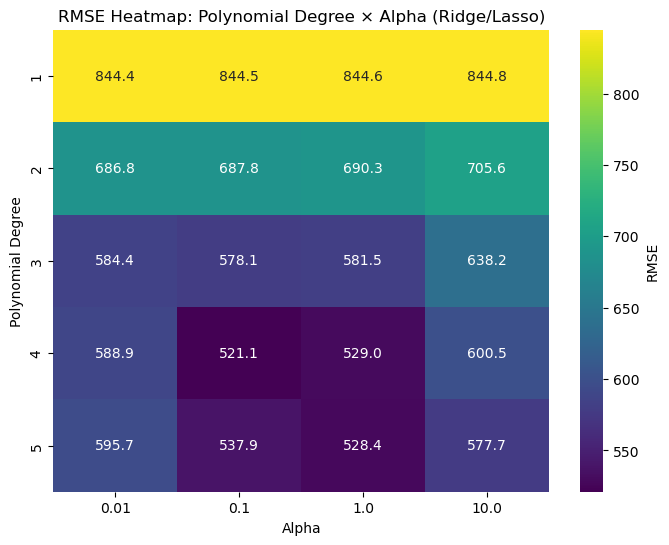

In [10]:
heatmap_data = results_df[results_df['alpha'].notna()]

pivot_table = heatmap_data.pivot_table(
    index='degree',
    columns='alpha',
    values='rmse',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="viridis", cbar_kws={"label": "RMSE"})
plt.title("RMSE Heatmap: Polynomial Degree × Alpha (Ridge/Lasso)")
plt.ylabel("Polynomial Degree")
plt.xlabel("Alpha")
plt.show()

In [11]:
best = cv_summary.iloc[0]
print("Best benchmark configuration:")
print(best)

Best benchmark configuration:
model             Lasso
degree                5
alpha               0.1
mean_rmse    456.040854
Name: 17, dtype: object


#### Train best regression model and evaluate the performance on the test set

In [12]:
poly = PolynomialFeatures(degree=int(best["degree"]), include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

norm = StandardScaler()
X_train_scaled = norm.fit_transform(X_train_poly)
X_test_scaled = norm.transform(X_test_poly)

if best["model"] == "Linear":
    final_reg = LinearRegression()
elif best["model"] == "Ridge":
    final_reg = Ridge(alpha=best["alpha"])
else:
    final_reg = Lasso(alpha=best["alpha"], max_iter=10000)

final_reg.fit(X_train_scaled, y_train)
y_test_pred = final_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")

MAE: 317.2279714131933
MAE (in percentage): 10.167563186320299
R2: 0.774499759982749
RMSE: 445.51328374290046


### Overall Performance of the Regression Models

The best regression model achieves a Mean Absolute Error (MAE) of approximately 317 minutes per hour. This means that, on average, the model’s hourly prediction deviates from the observed utilization by about 317 occupied charging minutes, aggregated across all charging stations.

Given a maximum site capacity of 3120 minutes per hour (52 charging stations × 60 minutes), this corresponds to a relative prediction error of around 10.2%. From an operational standpoint, this level of error is non-negligible, as it represents the equivalent of more than five fully occupied charging stations per hour.

The model achieves an R² of 0.77, indicating that 77% of the variance in hourly utilization is explained by the model. This suggests that the regression captures the main systematic demand patterns reasonably well and that utilization is not dominated by pure randomness.

However, the RMSE of 445 minutes per hour highlights that the model occasionally produces large prediction errors. These larger deviations are operationally critical, as underestimating utilization can lead to congestion, reduced service quality, and suboptimal operational decisions.

From an operational perspective, while the average error may appear acceptable relative to total capacity, the magnitude of peak-related errors limits the model’s suitability for reliable utilization forecasting and decision support.

Therefore, despite its reasonable explanatory power, this regression model does not sufficiently meet the operational requirements.

Let's stick to our initial thoughts and build up some Neural Networks to see if we can get better results!

## Neural Network

### NN for Site 1

First we build up a NN for Site 1 with common hyperparameters, to see if a NN is better suitable for this task.

We have already defined the target variable and features for the regression models, and split the data into training, validation, and test sets.

We can still all of this to buid up our NN

In [13]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras import Sequential # sequential model: https://keras.io/guides/sequential_model/
from keras.layers import Dense, Dropout
from keras.regularizers import l2

%matplotlib inline

#### Scale the data

In [14]:
norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

#### Build the NN
We use a common neural network architecture from the lecture, but we also include the Keras L2 regularizer to reduce overfitting and improve the model’s generalization to new data.

For the output layer we use ReLu as activation function because the target variable is strictly non-negative by definition.

In [ ]:
predictor = Sequential()

predictor.add(Dense(units=64,
                     activation='relu',
                     input_shape=(14,)))

predictor.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
predictor.add(Dropout(0.05))

predictor.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
predictor.add(Dropout(0.05))

predictor.add(Dense(units=64, 
                     activation='relu', 
                     kernel_regularizer=l2(0.001)))
predictor.add(Dropout(0.05))

predictor.add(Dense(1, activation='relu'))

predictor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile the NN

In [16]:
predictor.compile(loss='mse',
             optimizer="adam",
             metrics=["mae", "mse"])

#### Train the NN

In [17]:
history = predictor.fit(X_norm_train, y_train,
                            validation_data=(X_norm_val, y_val),
                            epochs=100,
                            batch_size=50)

Epoch 1/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 873926.8750 - mae: 587.3012 - mse: 873926.4375 - val_loss: 716627.3125 - val_mae: 609.9588 - val_mse: 716626.8750
Epoch 2/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 662244.0000 - mae: 523.3638 - mse: 662243.6250 - val_loss: 588222.2500 - val_mae: 478.0304 - val_mse: 588222.0000
Epoch 3/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 456886.9062 - mae: 396.4542 - mse: 456886.2500 - val_loss: 288508.5625 - val_mae: 297.4817 - val_mse: 288507.7812
Epoch 4/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 241437.4844 - mae: 253.3128 - mse: 241436.8125 - val_loss: 189029.6562 - val_mae: 208.4492 - val_mse: 189028.7344
Epoch 5/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 181992.1094 - mae: 207.9402 - mse: 181991.1875 - val_loss: 153084.7656 - val_mae: 183.6126 - val_mse: 153083.7500
Epoch 6/100
284/284 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 163455.0312 - mae: 193.9570 - mse: 163454.0469 - val_loss:

#### Results of the NN

In [18]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,873926.875000,587.301208,873926.437500,716627.312500,609.958801,716626.875000
1,662244.000000,523.363831,662243.625000,588222.250000,478.030396,588222.000000
2,456886.906250,396.454224,456886.250000,288508.562500,297.481689,288507.781250
3,241437.484375,253.312836,241436.812500,189029.656250,208.449188,189028.734375
4,181992.109375,207.940170,181991.187500,153084.765625,183.612610,153083.750000
...,...,...,...,...,...,...
95,39220.964844,90.925583,39217.406250,62005.394531,100.198700,62001.839844
96,43043.167969,94.425209,43039.632812,53578.042969,93.489685,53574.484375
97,40400.507812,92.924042,40396.937500,55291.585938,93.096687,55288.003906
98,39377.769531,91.853638,39374.187500,48944.238281,89.875076,48940.597656


In [19]:
root_metrics_df = history_df[["mse", "val_mse"]].apply(np.sqrt)
root_metrics_df.rename({"mse":"rmse", "val_mse":"val_rmse"}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,934.840327,846.538171
1,813.783525,766.956322
2,675.933614,537.129203
3,491.362201,434.774349
4,426.604252,391.259185
...,...,...
95,198.033851,249.001686
96,207.459955,231.461626
97,200.989894,235.134013
98,198.429301,221.225219


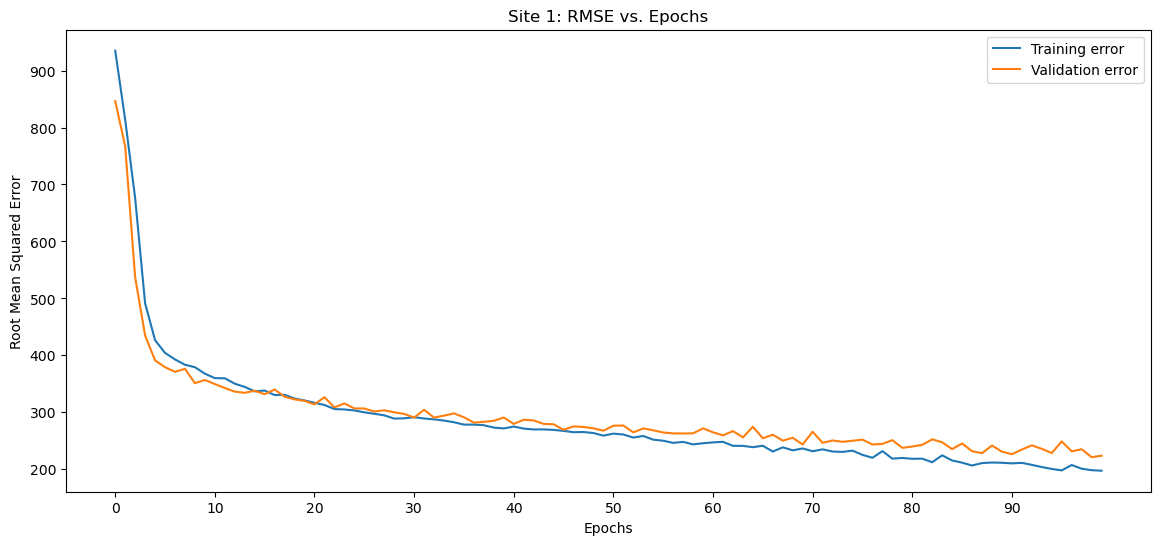

In [20]:
plt.figure(figsize=(14,6), dpi=100)

plt.plot(root_metrics_df["rmse"], label = 'Training error')
plt.plot(root_metrics_df["val_rmse"], label = 'Validation error')

plt.xlabel("Epochs")
plt.ylabel("Root Mean Squared Error")

plt.xticks(range(0,100,10))
plt.legend()
plt.title("Site 1: RMSE vs. Epochs")

plt.show()

#### Evaluate Performance on Test Set regarding our performance criterions.

In [21]:
y_pred = predictor.predict(X_norm_test)

148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")

MAE: 91.41262691261961
MAE (in percentage): 2.929891888224988
R2: 0.9456253256200513
RMSE: 218.7688521757159


### Overall Performance of the initial NN

We can now definitly see, that are results are way better than for our regression models!

The neural network developed for Site 1 achieves a Mean Absolute Error (MAE) of 91,41 minutes per hour. This indicates that, on average, the model deviates from the observed hourly utilization by approximately 91,41 occupied charging minutes.

Given the maximum capacity of 3120 minutes per hour (52 charging stations × 60 minutes), the MAE corresponds to a relative prediction error of 2,93%.

The R² of 0,95 shows that the model explains over 95% of the observed variance in hourly utilization. This high explanatory power (Value near 1) indicates that the neural network captures systematic demand patterns rather than merely fitting random fluctuations in the data.

In addition, the model achieves a RMSE of 218,77 minutes per hour. Since RMSE penalizes larger deviations more strongly than MAE, this metric provides insight into the presence and impact of occasional large prediction errors. The relatively low RMSE value in relation to the MAE indicates stable model behavior and suggests that large misestimations are infrequent.

From an operational perspective, an average error of approximately 2,93% of the total site capacity
is considered acceptable for utilization forecasting and decision support. The combination of low
absolute and relative errors, together with high R² values, confirms that the model provides both
accurate and structurally meaningful predictions.

Given these strong initial results, the neural network approach is deemed more suitable for the given
prediction task. Consequently, the subsequent analysis focuses on systematic hyperparameter tuning
to further improve model performance and robustness.

### Finding the best hyperparamters

To find the best hyperperameters we use Random Search strategy. Random Search has been shown to be
more efficient than grid search in high-dimensional hyperparameter spaces, as it explores a broader range of configurations while remaining computationally tractable.

Because the results for Site 1 and 2 were very similar and our prediction use-case ist only for Site **X** we use the data from this site.

#### Import futher librarys

In [23]:
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from scipy.stats import uniform, randint
from sklearn.model_selection import ParameterSampler

#### Build up the NN as a function

We use the same components as for the NNs above, but define a function for building up the NNs

In [ ]:
def build_NN(
    num_hidden_layers=2,
    units_hidden=32,
    dropout_rate=0.2,
    regularization=0.001
):
    """
    This function builds and compiles a feedforward neural network for regression tasks.

    The network consists of an input layer, a configurable number of hidden layers with ReLU activation,
    L2 regularization, and dropout for regularization, followed by a single-node output layer.

    Parameters:
    - 'num_hidden_layers': number of hidden layers
    - 'units_hidden': number of units per hidden layer
    - 'dropout_rate': dropout rate applied after each hidden layer
    - 'regularization': L2 regularization strength

    Returns:
    - Compiled Keras Sequential model
    """
    predictor = Sequential()
    predictor.add(Dense(units=units_hidden,
                     activation='relu',
                     input_shape=(14,)))

    for _ in range(num_hidden_layers):
        predictor.add(Dense(
            units_hidden,
            activation="relu",
            kernel_regularizer=l2(regularization)
        ))
        predictor.add(Dropout(dropout_rate))

    predictor.add(Dense(1, activation="relu"))

    predictor.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae", "mse"]
    )
    
    return predictor

#### Define randomly sampled hyperparameter

The following hyperparameters are randomly sampled to explore a wide range of possible
network configurations while remaining computationally feasible.

In [25]:
distributions = {
    "num_hidden_layers": randint(2, 6),
    "units_hidden": randint(32, 256),
    "dropout_rate": uniform(0.05, 0.35),
    "regularization": uniform(1e-5, 5e-3),
    "epochs": randint(50, 150),
    "batch_size": randint(16, 128)
}


param_list = list(ParameterSampler(
    distributions,
    n_iter=10,
    random_state=42
))

#### Random search function, finding the best hyperparameters

To improve the robustness of the hyperparameter selection, each randomly sampled
network configuration is evaluated using **5 different train/validation/test splits**.

This nested evaluation reduces the risk of selecting hyperparameters that perform well
only on a single data split and ensures that the chosen configuration generalizes
consistently across different temporal and structural data variations.

In [26]:
best_score = float("inf")
best_params = None
best_model = None

for params in param_list:
    print(f"Testing combination: {params}")
    val_losses = []

    for seed in range(5):
        X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=seed)

        scaler = StandardScaler()
        X_norm_train = scaler.fit_transform(X_train)
        X_norm_val = scaler.transform(X_val)

        model = build_NN(
            num_hidden_layers=params["num_hidden_layers"],
            units_hidden=params["units_hidden"],
            dropout_rate=params["dropout_rate"],
            regularization=params["regularization"]
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        history = model.fit(
            X_norm_train,
            y_train,
            validation_data=(X_norm_val, y_val),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=0,
            callbacks=[early_stopping]
        )

        val_losses.append(min(history.history["val_loss"]))

    mean_val_loss = np.mean(val_losses)

    if mean_val_loss < best_score:
        best_score = mean_val_loss
        best_params = params
        best_model = model

Testing combination: {'batch_size': 118, 'dropout_rate': np.float64(0.3287900454010815), 'epochs': 64, 'num_hidden_layers': 4, 'regularization': np.float64(0.0039084550013638465), 'units_hidden': 52}
Testing combination: {'batch_size': 118, 'dropout_rate': np.float64(0.2060414634987569), 'epochs': 136, 'num_hidden_layers': 4, 'regularization': np.float64(0.002306244459829336), 'units_hidden': 148}
Testing combination: {'batch_size': 115, 'dropout_rate': np.float64(0.10000338627267927), 'epochs': 52, 'num_hidden_layers': 3, 'regularization': np.float64(0.00029205789513550134), 'units_hidden': 119}
Testing combination: {'batch_size': 123, 'dropout_rate': np.float64(0.3784934481555125), 'epochs': 51, 'num_hidden_layers': 5, 'regularization': np.float64(0.004971057796456087), 'units_hidden': 192}
Testing combination: {'batch_size': 91, 'dropout_rate': np.float64(0.2640786061708983), 'epochs': 138, 'num_hidden_layers': 2, 'regularization': np.float64(0.002633873301291946), 'units_hidden': 2

#### Best Hyperparameters Found

In [27]:
print("Best parameters found:")
print(best_params)
print("Best validation loss:", best_score)

Best parameters found:
{'batch_size': 107, 'dropout_rate': np.float64(0.20405337280886043), 'epochs': 120, 'num_hidden_layers': 5, 'regularization': np.float64(0.002485884550556351), 'units_hidden': 206}
Best validation loss: 49711.4375


### Finally: Build up the "best model" with the best hyperparamaters

In [28]:
y = site1["total minutes of parking"]
X = site1.drop(columns=["total minutes of parking"])

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

norm = StandardScaler()
norm.fit(X_train)

X_norm_train = norm.transform(X_train)
X_norm_val = norm.transform(X_val)
X_norm_test = norm.transform(X_test)

final_model = build_NN(
            num_hidden_layers=best_params["num_hidden_layers"],
            units_hidden=best_params["units_hidden"],
            dropout_rate=best_params["dropout_rate"],
            regularization=best_params["regularization"]
        )

history = final_model.fit(
            X_norm_train,
            y_train,
            validation_data=(X_norm_val, y_val),
            epochs=best_params["epochs"],
            batch_size=best_params["batch_size"],
        )       

Epoch 1/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 787231.6875 - mae: 543.8773 - mse: 787229.1250 - val_loss: 500082.9062 - val_mae: 400.3420 - val_mse: 500080.0625
Epoch 2/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 302894.1250 - mae: 295.8373 - mse: 302891.3125 - val_loss: 184142.8438 - val_mae: 229.9662 - val_mse: 184139.7969
Epoch 3/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 181492.3906 - mae: 214.8662 - mse: 181489.3125 - val_loss: 148792.0156 - val_mae: 185.9970 - val_mse: 148788.8594
Epoch 4/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 165700.7500 - mae: 201.0700 - mse: 165697.4844 - val_loss: 143156.1406 - val_mae: 174.8386 - val_mse: 143152.8438
Epoch 5/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 145538.1406 - mae: 188.5604 - mse: 145534.7500 - val_loss: 120708.3281 - val_mae: 156.4625 - val_mse: 120704.8125
Epoch 6/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 130849.1250 - mae: 174.9978 - mse: 130845.5312 - val_loss:

#### Results of the best model

In [29]:
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,mse,val_loss,val_mae,val_mse
0,787231.687500,543.877258,787229.125000,500082.906250,400.341980,500080.062500
1,302894.125000,295.837341,302891.312500,184142.843750,229.966202,184139.796875
2,181492.390625,214.866226,181489.312500,148792.015625,185.996994,148788.859375
3,165700.750000,201.070007,165697.484375,143156.140625,174.838623,143152.843750
4,145538.140625,188.560379,145534.750000,120708.328125,156.462479,120704.812500
...,...,...,...,...,...,...
115,19974.941406,71.159882,19963.625000,25649.156250,71.091789,25637.816406
116,20872.449219,70.012550,20861.085938,24873.396484,66.101967,24862.011719
117,19647.099609,70.066444,19635.677734,22938.230469,63.703876,22926.787109
118,18951.376953,69.407135,18939.916016,21082.431641,62.717842,21070.902344


In [30]:
root_metrics_df = history_df[["mse", "val_mse"]].apply(np.sqrt)
root_metrics_df.rename({"mse":"rmse", "val_mse":"val_rmse"}, axis=1, inplace=True)
root_metrics_df

,rmse,val_rmse
0,887.259334,707.163392
1,550.355624,429.115132
2,426.015625,385.731590
3,407.059559,378.355446
4,381.490170,347.425981
...,...,...
115,141.292693,160.118133
116,144.433673,157.676922
117,140.127363,151.415941
118,137.622367,145.158198


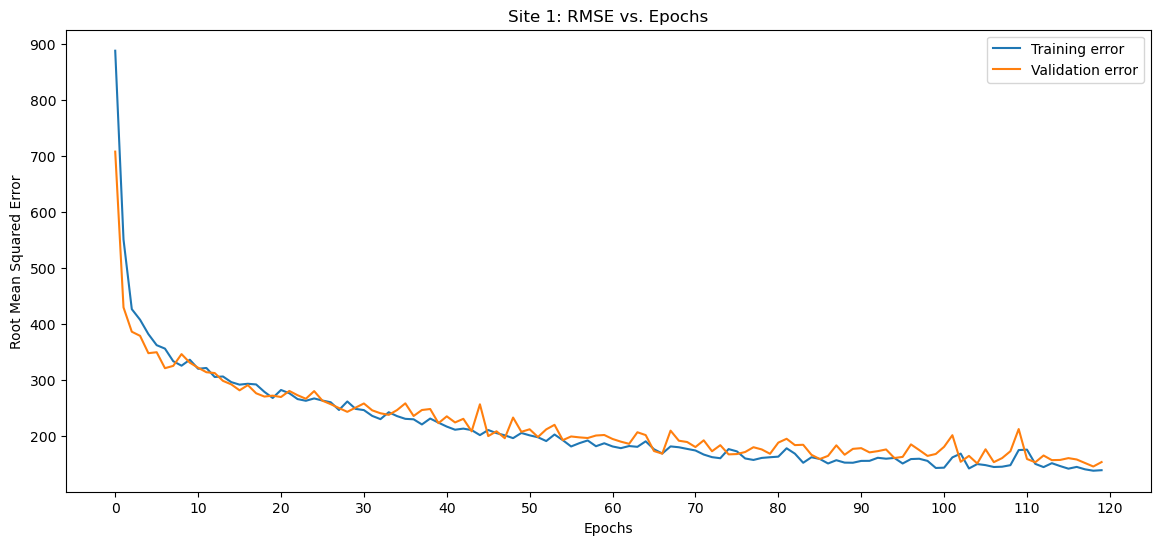

In [31]:
epochs = best_params["epochs"] + 1

plt.figure(figsize=(14,6), dpi=100)

plt.plot(root_metrics_df["rmse"], label = 'Training error')
plt.plot(root_metrics_df["val_rmse"], label = 'Validation error')

plt.xlabel("Epochs")
plt.ylabel("Root Mean Squared Error")

plt.xticks(range(0, epochs, 10))
plt.legend()
plt.title("Site 1: RMSE vs. Epochs")

plt.show()

#### Evaluate the performance of the best model

In [32]:
y_pred = final_model.predict(X_norm_test)

148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [33]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

MAX_MINUTES_PER_HOUR = 52 * 60
mae_percentage = mae / MAX_MINUTES_PER_HOUR * 100

print(f"MAE: {mae}")
print(f"MAE (in percentage): {mae_percentage}")
print(f"R2: {r2}")
print(f"RMSE: {rmse}")

MAE: 62.19738843642597
MAE (in percentage): 1.9935060396290374
R2: 0.9770451974970197
RMSE: 142.14249486518978


### Overall Performance of the NN with the best hyperparameters

We could further improve our initial Neural Network by finding the best (regarding our hardware) hyperparamters. 


The final results are the following (Jump to [here](#overall-performance-of-the-initial-nn) for the interpretation of the values):
- MAE: 62.20
- MAE (in percentage): 1,99%
- R2: 0,98
- RMSE 142,14

These findings confirm that constructing a neural network and applying random search for hyperparameter optimization was a worthwhile approach, leading to a robust and accurate model!